In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Project Folder Structure

In [2]:
import os

# Main Project Path
PROJECT_PATH = "/content/drive/MyDrive/GM_Colorization_Project"

folders = [
    "dataset",
    "checkpoints",
    "generated_images",
    "generated_images/final_results",
    "plots",
    "metrics",
    "logs",
    "reports"
]

# Create folders
for folder in folders:
    os.makedirs(os.path.join(PROJECT_PATH, folder), exist_ok=True)

print("Project folders created successfully!")
print("Project Path:", PROJECT_PATH)

Project folders created successfully!
Project Path: /content/drive/MyDrive/GM_Colorization_Project


Install Required Libraries

In [3]:
!pip install -q torch torchvision matplotlib tqdm pillow scikit-image

mport Libraries + Set Device

In [4]:
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


Download CIFAR-10 Dataset

In [5]:
# Dataset path
DATASET_PATH = os.path.join(PROJECT_PATH, "dataset")

# Transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Train Dataset
train_dataset = CIFAR10(
    root=DATASET_PATH,
    train=True,
    download=True,
    transform=transform
)

# Test Dataset
test_dataset = CIFAR10(
    root=DATASET_PATH,
    train=False,
    download=True,
    transform=transform
)

print("Train Dataset Size:", len(train_dataset))
print("Test Dataset Size:", len(test_dataset))

100%|██████████| 170M/170M [06:41<00:00, 425kB/s]


Train Dataset Size: 50000
Test Dataset Size: 10000


Show Sample CIFAR-10 Images

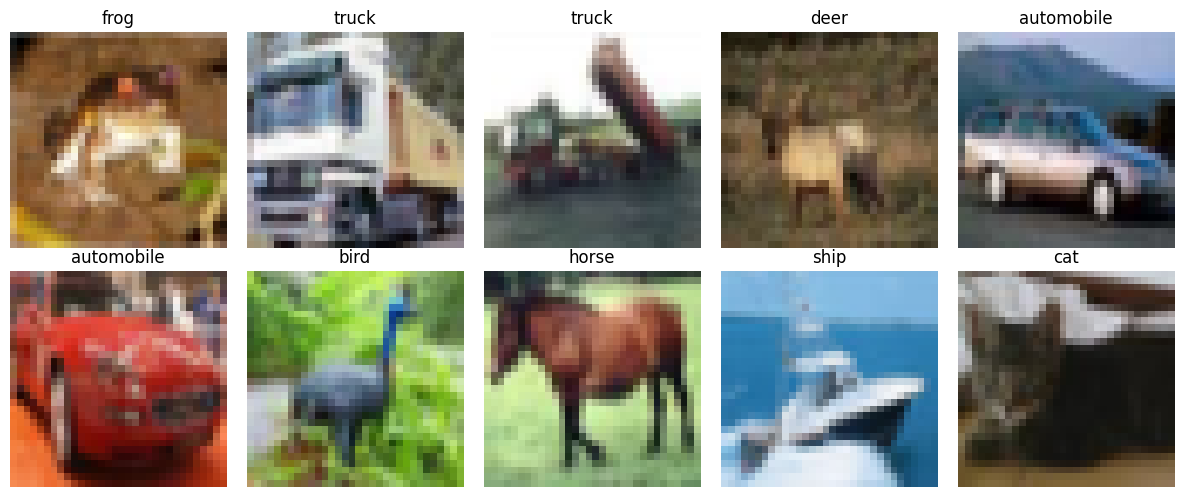

In [6]:
# CIFAR-10 Classes
classes = train_dataset.classes

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    # Convert tensor to numpy
    image = image.permute(1, 2, 0).numpy()

    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

Convert RGB Image → Grayscale + Visualize

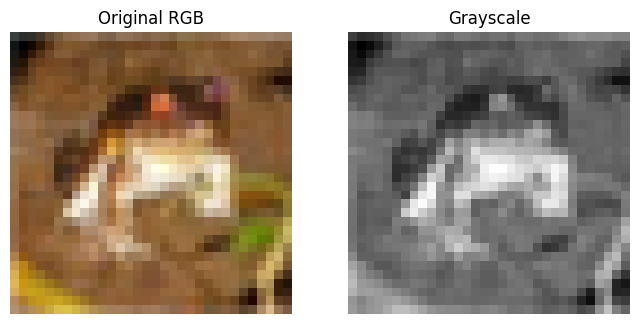

In [7]:
import torchvision.transforms.functional as TF

# Get one sample image
image, label = train_dataset[0]

# Convert RGB to Grayscale
gray_image = TF.rgb_to_grayscale(image)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(8,4))

# Original RGB
ax[0].imshow(image.permute(1,2,0))
ax[0].set_title("Original RGB")
ax[0].axis("off")

# Grayscale
ax[1].imshow(gray_image.squeeze(), cmap="gray")
ax[1].set_title("Grayscale")
ax[1].axis("off")

plt.show()

Create Custom Dataset for Pix2Pix

In [8]:
class ColorizationDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        rgb_image, _ = self.dataset[idx]

        # Convert RGB → Grayscale
        gray_image = TF.rgb_to_grayscale(rgb_image)

        return gray_image, rgb_image


# Create datasets
train_color_dataset = ColorizationDataset(train_dataset)
test_color_dataset = ColorizationDataset(test_dataset)

print("Custom Dataset Created Successfully!")
print("Train Samples:", len(train_color_dataset))
print("Test Samples:", len(test_color_dataset))

Custom Dataset Created Successfully!
Train Samples: 50000
Test Samples: 10000


DataLoaders

In [9]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_color_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_color_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train Batches:", len(train_loader))
print("Test Batches:", len(test_loader))

Train Batches: 782
Test Batches: 157


Check One Batch Shape

In [10]:
# Get one batch
gray_images, color_images = next(iter(train_loader))

print("Grayscale Batch Shape :", gray_images.shape)
print("Color Batch Shape     :", color_images.shape)

Grayscale Batch Shape : torch.Size([64, 1, 32, 32])
Color Batch Shape     : torch.Size([64, 3, 32, 32])


Visualize Batch (Gray → Color)

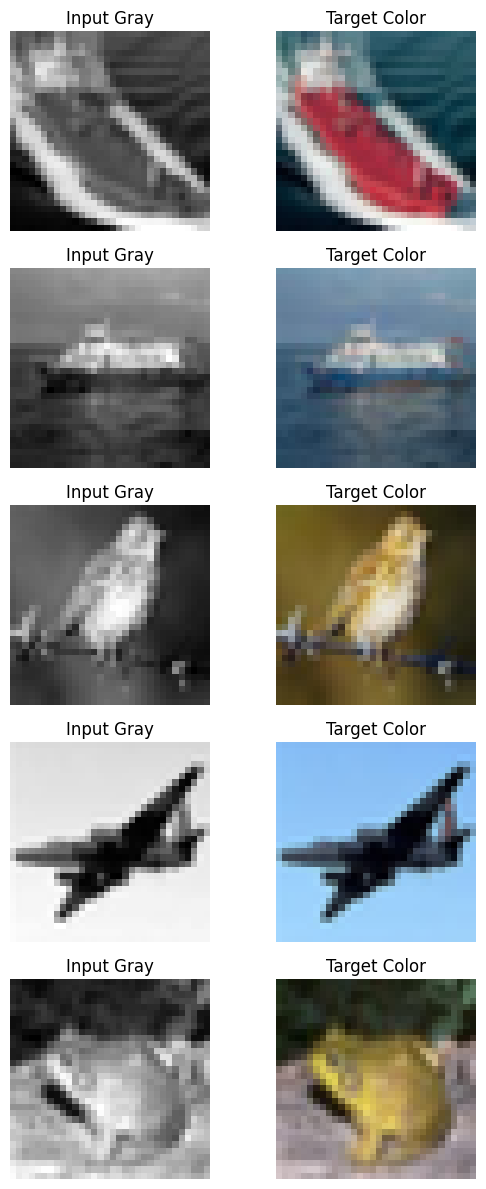

In [11]:
# Show first 5 samples
fig, axes = plt.subplots(5, 2, figsize=(6,12))

for i in range(5):

    # Grayscale image
    gray = gray_images[i].squeeze().numpy()

    # RGB image
    color = color_images[i].permute(1,2,0).numpy()

    # Gray
    axes[i,0].imshow(gray, cmap="gray")
    axes[i,0].set_title("Input Gray")
    axes[i,0].axis("off")

    # RGB
    axes[i,1].imshow(color)
    axes[i,1].set_title("Target Color")
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

Build Generator

In [12]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # Input: 1 x 32 x 32
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),

            # 64 x 16 x 16
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 8 x 8
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 x 16 x 16
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()

            # Output: 3 x 32 x 32
        )

    def forward(self, x):
        return self.model(x)


# Create generator
generator = Generator().to(device)

print(generator)

Generator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): Tanh()
  )
)


Test Generator Output Shape

In [13]:
# Move one batch to GPU
gray_images = gray_images.to(device)

# Generator output
fake_color = generator(gray_images)

print("Generator Output Shape:", fake_color.shape)

Generator Output Shape: torch.Size([64, 3, 32, 32])


Build Discriminator (PatchGAN)

In [14]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # Input = Gray(1) + RGB(3) = 4 channels
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 1, kernel_size=4, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, gray, color):

        # Concatenate grayscale + color image
        x = torch.cat([gray, color], dim=1)

        return self.model(x)


# Create discriminator
discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(4, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (6): Sigmoid()
  )
)


Test Discriminator Output

In [15]:
# Real output
real_output = discriminator(gray_images, color_images.to(device))

# Fake output
fake_output = discriminator(gray_images, fake_color)

print("Real Output Shape :", real_output.shape)
print("Fake Output Shape :", fake_output.shape)

Real Output Shape : torch.Size([64, 1, 7, 7])
Fake Output Shape : torch.Size([64, 1, 7, 7])


Define Loss Functions + Optimizers

In [16]:
import torch.optim as optim

# Adversarial Loss
adversarial_loss = nn.BCELoss()

# Pixel-wise Loss
l1_loss = nn.L1Loss()

# Optimizers
generator_optimizer = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

discriminator_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Loss functions and optimizers initialized successfully!")

Loss functions and optimizers initialized successfully!


Create Labels for GAN Training

In [17]:
# PatchGAN output shape
PATCH = (1, 7, 7)

# Real labels = 1
real_labels = torch.ones((BATCH_SIZE, *PATCH)).to(device)

# Fake labels = 0
fake_labels = torch.zeros((BATCH_SIZE, *PATCH)).to(device)

print("Real Labels Shape :", real_labels.shape)
print("Fake Labels Shape :", fake_labels.shape)

Real Labels Shape : torch.Size([64, 1, 7, 7])
Fake Labels Shape : torch.Size([64, 1, 7, 7])


Function to Save Generated Images

In [19]:
import os

def save_generated_images(epoch, gray, fake, real):

    save_path = os.path.join(
        PROJECT_PATH,
        "generated_images",
        f"epoch_{epoch}"
    )

    os.makedirs(save_path, exist_ok=True)

    fig, axes = plt.subplots(3, 5, figsize=(12,8))

    for i in range(5):

        # Gray Input
        axes[0, i].imshow(gray[i].cpu().squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("Gray")

        # Generated
        fake_img = fake[i].cpu().detach().permute(1,2,0).numpy()
        fake_img = (fake_img + 1) / 2

        axes[1, i].imshow(fake_img)
        axes[1, i].axis("off")
        axes[1, i].set_title("Generated")

        # Real
        real_img = real[i].cpu().permute(1,2,0).numpy()

        axes[2, i].imshow(real_img)
        axes[2, i].axis("off")
        axes[2, i].set_title("Real")

    plt.tight_layout()

    image_file = os.path.join(save_path, f"results_epoch_{epoch}.png")

    plt.savefig(image_file)
    plt.close()

    print(f"Images saved at: {image_file}")

Checkpoint Saving Function

In [20]:
def save_checkpoint(epoch, best_g_loss):

    checkpoint = {
        "epoch": epoch,
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "generator_optimizer": generator_optimizer.state_dict(),
        "discriminator_optimizer": discriminator_optimizer.state_dict(),
        "best_g_loss": best_g_loss
    }

    checkpoint_path = os.path.join(
        PROJECT_PATH,
        "checkpoints",
        "last_checkpoint.pth"
    )

    torch.save(checkpoint, checkpoint_path)

    print(f"Checkpoint saved at epoch {epoch}")

Best Model Saving Function

In [21]:
def save_best_models():

    generator_path = os.path.join(
        PROJECT_PATH,
        "checkpoints",
        "best_generator.pth"
    )

    discriminator_path = os.path.join(
        PROJECT_PATH,
        "checkpoints",
        "best_discriminator.pth"
    )

    torch.save(generator.state_dict(), generator_path)
    torch.save(discriminator.state_dict(), discriminator_path)

    print("Best models saved successfully!")

Initialize Training Variables

In [22]:
# Training settings
EPOCHS = 20

# Store losses
generator_losses = []
discriminator_losses = []

# Best generator loss
best_g_loss = float("inf")

print("Training variables initialized!")
print("Epochs:", EPOCHS)

Training variables initialized!
Epochs: 20


Training Loop

In [23]:
for epoch in range(EPOCHS):

    generator.train()
    discriminator.train()

    g_running_loss = 0.0
    d_running_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for gray_images, real_images in loop:

        gray_images = gray_images.to(device)
        real_images = real_images.to(device)

        batch_size = gray_images.size(0)

        # Labels
        real_labels = torch.ones((batch_size, 1, 7, 7)).to(device)
        fake_labels = torch.zeros((batch_size, 1, 7, 7)).to(device)

        # =========================================
        # TRAIN DISCRIMINATOR
        # =========================================

        discriminator_optimizer.zero_grad()

        # Real images
        real_output = discriminator(gray_images, real_images)

        d_real_loss = adversarial_loss(real_output, real_labels)

        # Fake images
        fake_images = generator(gray_images)

        fake_output = discriminator(gray_images, fake_images.detach())

        d_fake_loss = adversarial_loss(fake_output, fake_labels)

        # Total discriminator loss
        d_loss = (d_real_loss + d_fake_loss) / 2

        d_loss.backward()

        discriminator_optimizer.step()

        # =========================================
        # TRAIN GENERATOR
        # =========================================

        generator_optimizer.zero_grad()

        fake_images = generator(gray_images)

        fake_output = discriminator(gray_images, fake_images)

        # GAN loss
        g_adv_loss = adversarial_loss(fake_output, real_labels)

        # L1 reconstruction loss
        g_l1_loss = l1_loss(fake_images, real_images)

        # Total generator loss
        g_loss = g_adv_loss + (100 * g_l1_loss)

        g_loss.backward()

        generator_optimizer.step()

        # =========================================
        # STORE LOSSES
        # =========================================

        g_running_loss += g_loss.item()
        d_running_loss += d_loss.item()

        loop.set_postfix(
            G_Loss=g_loss.item(),
            D_Loss=d_loss.item()
        )

    # Average losses
    avg_g_loss = g_running_loss / len(train_loader)
    avg_d_loss = d_running_loss / len(train_loader)

    generator_losses.append(avg_g_loss)
    discriminator_losses.append(avg_d_loss)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Generator Loss    : {avg_g_loss:.4f}")
    print(f"Discriminator Loss: {avg_d_loss:.4f}")

    # Save checkpoint
    save_checkpoint(epoch + 1, best_g_loss)

    # Save best model
    if avg_g_loss < best_g_loss:

        best_g_loss = avg_g_loss

        save_best_models()

    # Save generated samples
    save_generated_images(
        epoch + 1,
        gray_images,
        fake_images,
        real_images
    )

Epoch [1/20]: 100%|██████████| 782/782 [00:19<00:00, 40.52it/s, D_Loss=0.126, G_Loss=15.5]



Epoch [1/20]
Generator Loss    : 11.3945
Discriminator Loss: 0.2366
Checkpoint saved at epoch 1
Best models saved successfully!
Images saved at: /content/drive/MyDrive/GM_Colorization_Project/generated_images/epoch_1/results_epoch_1.png


Epoch [2/20]: 100%|██████████| 782/782 [00:19<00:00, 39.95it/s, D_Loss=0.0665, G_Loss=11.9]



Epoch [2/20]
Generator Loss    : 10.3562
Discriminator Loss: 0.1487
Checkpoint saved at epoch 2
Best models saved successfully!
Images saved at: /content/drive/MyDrive/GM_Colorization_Project/generated_images/epoch_2/results_epoch_2.png


Epoch [3/20]: 100%|██████████| 782/782 [00:19<00:00, 41.12it/s, D_Loss=0.0806, G_Loss=16]


...


Epoch [18/20]
Generator Loss    : 16.5865
Discriminator Loss: 0.0018
Checkpoint saved at epoch 18
Images saved at: /content/drive/MyDrive/GM_Colorization_Project/generated_images/epoch_18/results_epoch_18.png


Epoch [19/20]: 100%|██████████| 782/782 [00:20<00:00, 38.47it/s, D_Loss=0.000415, G_Loss=19.2]



Epoch [19/20]
Generator Loss    : 17.2631
Discriminator Loss: 0.0009
Checkpoint saved at epoch 19
Images saved at: /content/drive/MyDrive/GM_Colorization_Project/generated_images/epoch_19/results_epoch_19.png


Epoch [20/20]: 100%|██████████| 782/782 [00:18<00:00, 41.75it/s, D_Loss=0.00702, G_Loss=16.1]



Epoch [20/20]
Generator Loss    : 14.7590
Discriminator Loss: 0.1089
Checkpoint saved at epoch 20
Images saved at: /content/drive/MyDrive/GM_Colorization_Project/generated_images/epoch_20/results_epoch_20.png


lot Generator & Discriminator Loss Graphs

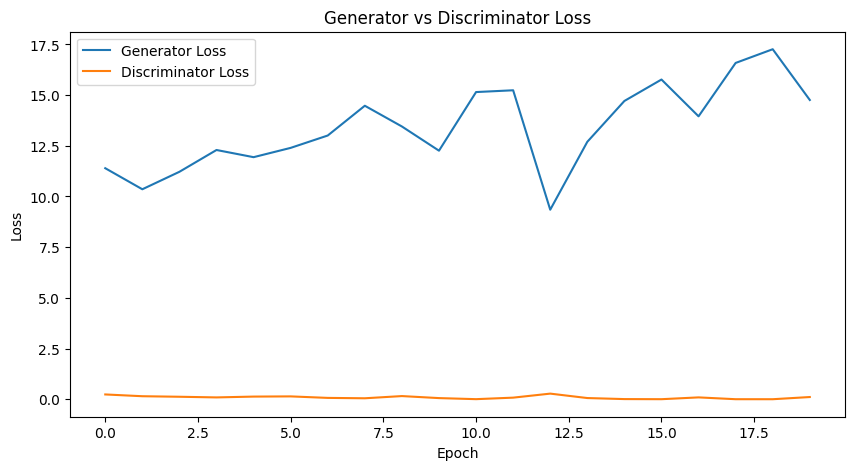

Loss graph saved at:
/content/drive/MyDrive/GM_Colorization_Project/plots/loss_curve.png


In [24]:
# Plot losses

plt.figure(figsize=(10,5))

plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator vs Discriminator Loss")

plt.legend()

# Save graph
plot_path = os.path.join(
    PROJECT_PATH,
    "plots",
    "loss_curve.png"
)

plt.savefig(plot_path)

plt.show()

print("Loss graph saved at:")
print(plot_path)

Load Best Generator Model

In [25]:
# Path of best generator
best_generator_path = os.path.join(
    PROJECT_PATH,
    "checkpoints",
    "best_generator.pth"
)

# Load best weights
generator.load_state_dict(
    torch.load(best_generator_path)
)

generator.eval()

print("Best Generator Loaded Successfully!")

Best Generator Loaded Successfully!


Generate Results on Test Images

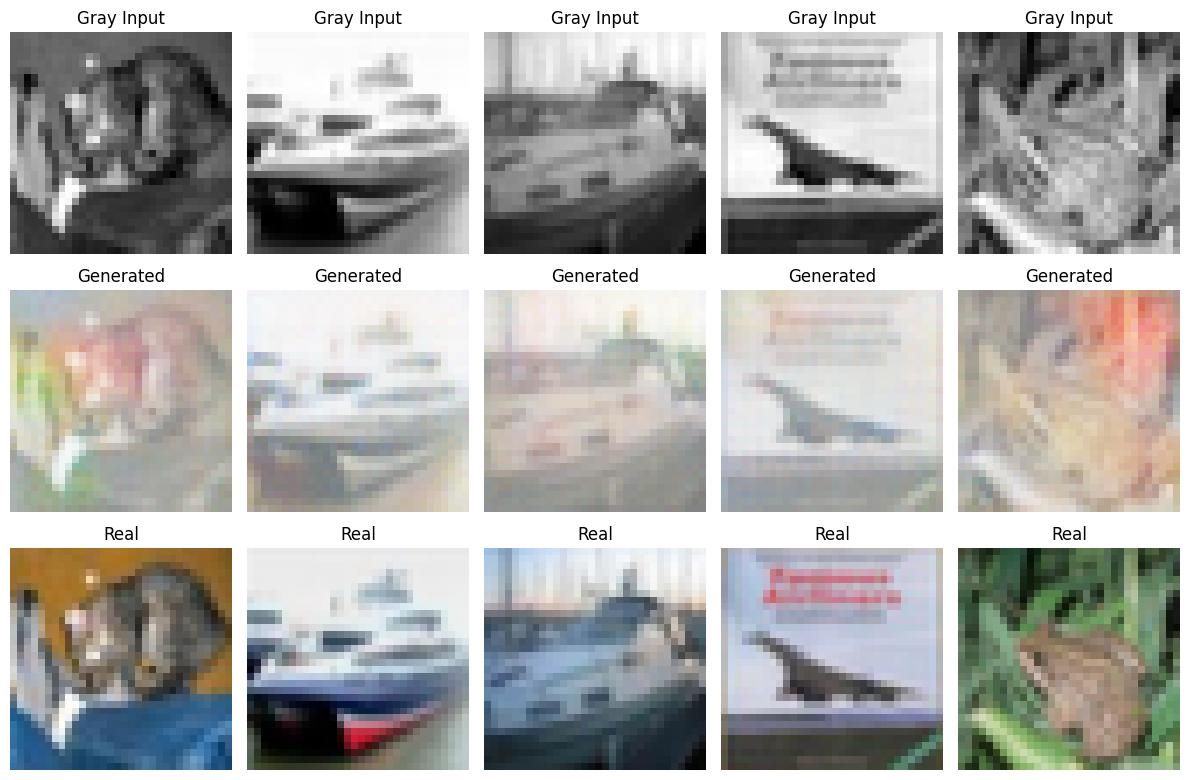

Test results saved at:
/content/drive/MyDrive/GM_Colorization_Project/generated_images/final_results/test_results.png


In [26]:
# Get one batch from test loader
gray_test, real_test = next(iter(test_loader))

gray_test = gray_test.to(device)
real_test = real_test.to(device)

# Generate color images
with torch.no_grad():
    fake_test = generator(gray_test)

# Plot results
fig, axes = plt.subplots(3, 5, figsize=(12,8))

for i in range(5):

    # Gray Input
    axes[0, i].imshow(
        gray_test[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")
    axes[0, i].set_title("Gray Input")

    # Generated Image
    fake_img = fake_test[i].cpu().permute(1,2,0).numpy()
    fake_img = (fake_img + 1) / 2
    fake_img = np.clip(fake_img, 0, 1)

    axes[1, i].imshow(fake_img)
    axes[1, i].axis("off")
    axes[1, i].set_title("Generated")

    # Real Image
    real_img = real_test[i].cpu().permute(1,2,0).numpy()

    axes[2, i].imshow(real_img)
    axes[2, i].axis("off")
    axes[2, i].set_title("Real")

plt.tight_layout()

# Save results
result_path = os.path.join(
    PROJECT_PATH,
    "generated_images",
    "final_results",
    "test_results.png"
)

plt.savefig(result_path)

plt.show()

print("Test results saved at:")
print(result_path)

Calculate PSNR Metric

In [27]:
from skimage.metrics import peak_signal_noise_ratio as psnr

psnr_scores = []

# Convert tensors to numpy
for i in range(len(fake_test)):

    fake_img = fake_test[i].cpu().permute(1,2,0).numpy()
    real_img = real_test[i].cpu().permute(1,2,0).numpy()

    # Normalize generated image
    fake_img = (fake_img + 1) / 2
    fake_img = np.clip(fake_img, 0, 1)

    score = psnr(real_img, fake_img, data_range=1.0)

    psnr_scores.append(score)

avg_psnr = np.mean(psnr_scores)

print("Average PSNR Score:", avg_psnr)

Average PSNR Score: 10.71245021369171


Calculate SSIM Metric

In [28]:
from skimage.metrics import structural_similarity as ssim

ssim_scores = []

for i in range(len(fake_test)):

    fake_img = fake_test[i].cpu().permute(1,2,0).numpy()
    real_img = real_test[i].cpu().permute(1,2,0).numpy()

    # Normalize generated image
    fake_img = (fake_img + 1) / 2
    fake_img = np.clip(fake_img, 0, 1)

    score = ssim(
        real_img,
        fake_img,
        channel_axis=2,
        data_range=1.0
    )

    ssim_scores.append(score)

avg_ssim = np.mean(ssim_scores)

print("Average SSIM Score:", avg_ssim)

Average SSIM Score: 0.62652147


Upload & Load Custom Image

In [30]:
from google.colab import files

uploaded = files.upload()

Saving car.jpg to car.jpg


Load & Display Uploaded Image

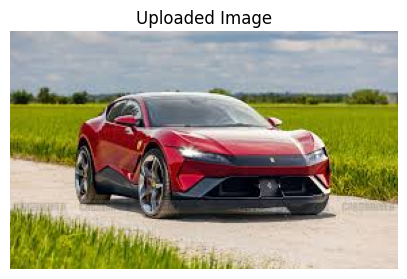

In [31]:
from PIL import Image
import matplotlib.pyplot as plt

# Load uploaded image
custom_image = Image.open("car.jpg").convert("RGB")

# Show image
plt.figure(figsize=(5,5))
plt.imshow(custom_image)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

Resize + Convert to Tensor + Create Grayscale

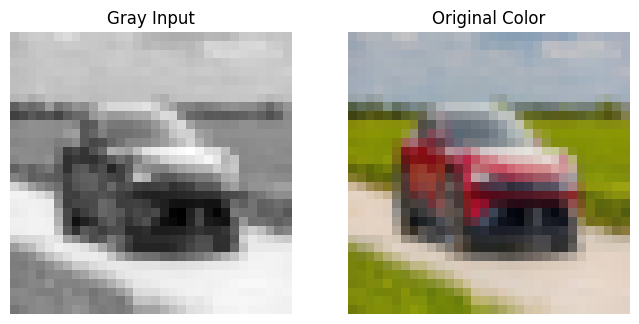

In [32]:
from torchvision import transforms
import torchvision.transforms.functional as TF

# Resize image to 32x32
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

# Apply transform
color_img = transform(custom_image)

# Convert to grayscale
gray_img = TF.rgb_to_grayscale(color_img)

# Show both
fig, ax = plt.subplots(1,2, figsize=(8,4))

# Gray
ax[0].imshow(gray_img.squeeze(), cmap="gray")
ax[0].set_title("Gray Input")
ax[0].axis("off")

# Real Color
ax[1].imshow(color_img.permute(1,2,0))
ax[1].set_title("Original Color")
ax[1].axis("off")

plt.show()

Generate Colorized Output using Trained GAN

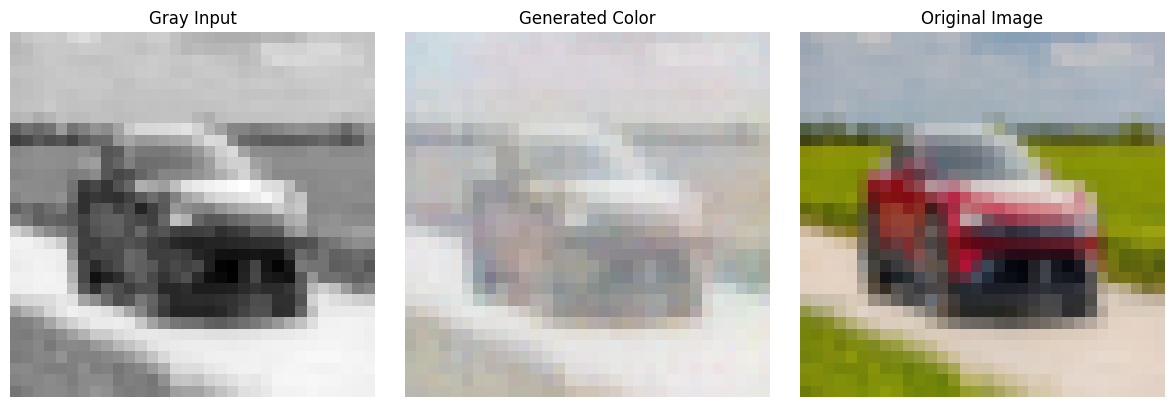

In [33]:
# Prepare grayscale image
input_gray = gray_img.unsqueeze(0).to(device)

# Generate color image
with torch.no_grad():
    generated_img = generator(input_gray)

# Convert output
generated_img = generated_img.squeeze(0).cpu().permute(1,2,0).numpy()

# Normalize output
generated_img = (generated_img + 1) / 2
generated_img = np.clip(generated_img, 0, 1)

# Plot results
fig, ax = plt.subplots(1,3, figsize=(12,4))

# Gray input
ax[0].imshow(gray_img.squeeze(), cmap="gray")
ax[0].set_title("Gray Input")
ax[0].axis("off")

# Generated
ax[1].imshow(generated_img)
ax[1].set_title("Generated Color")
ax[1].axis("off")

# Original
ax[2].imshow(color_img.permute(1,2,0))
ax[2].set_title("Original Image")
ax[2].axis("off")

plt.tight_layout()
plt.show()